# Understanding Neural Network Design: How `Depth` and `Width` Affect `Multilayer Perceptron (MLP)` Performance

### 1. Importing Required Libraries

In this section, I imported all the necessary libraries needed for this tutorial.

- `numpy` and `pandas` are used for handling numerical data and structuring the dataset.
- `matplotlib` is used to create visualisations that help illustrate the results.
- `scikit-learn` provides tools for loading the dataset, preprocessing the data, and building the **Multilayer Perceptron (MLP)** model.

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

### 2. Loading and Exploring the Dataset

The Breast Cancer Wisconsin dataset is used in this tutorial. It contains 569 samples with 30 numerical features describing properties of a cell nuclei.

The dataset is loaded using `load_breast_cancer()` available in scikit-learn. <br> By default, the features and target labels are stored separately, so they are combined into a single DataFrame for easier exploration before separating them into X and y for model training.

The target variable represents:
- 0 → malignant
- 1 → benign

`In the next three (3) code cells, I inspected:`
- The first few rows of the dataset
- The columns and shape of the dataset
- Summary statistics
- Whether there are any missing values

This step is important to understand the structure and quality of the data to be used before training any model

In [120]:
# Load the Breast Cancer dataset
data = load_breast_cancer()

# Convert dataset into a DataFrame for easier viewing
df = pd.DataFrame(data.data, columns=data.feature_names)


# Add target column (0 = malignant, 1 = benign)
df["target"] = data.target

# Display first 5 rows
df.head(20)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,0


In [102]:
print(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')


In [68]:
# View dataset shape (rows, columns)
print("Dataset shape:", df.shape)

# View summary statistics
df.describe()

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [25]:
# Check for missing values
print("Missing values: \n", df.isnull().sum())

Missing values: 
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


### 3. Data Preprocessing

Before training the model, the dataset needs to be prepared.

Firstly, the dataset is splited into:
- `Features (X):` all input variables
- `Target (y):` the label we want to predict

The data is then divided into training and testing sets using an 80/20 split. Where 20 is for testing and the remaining for training. <br> This allows the model to be trained on one portion of the data and evaluated on unseen data.

Feature scaling is applied using `StandardScaler`. This step is  important for neural networks, as they are sensitive to the scale of input features. Standardisation ensures that all features contribute equally to the learning process.

In [42]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardise features (important for neural networks)
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 4. Baseline Model

A baseline MLP model is created using a simple architecture with one hidden layer having 16 neurons.

This serves as a reference point for later experiments. By starting with a simple model, it will become easier to observe how increasing complexity (through depth and width) affects performance. `Depth` refers to the numnber of hidden layers between the input and output layers, while `Width` refers to the number of neurons within each layer. 

The model is trained on the training data and evaluated using accuracy on the test set.

`Note:` In this implementation, the **ReLU (Rectified Linear Unit)** activation function is used by default in the hidden layers of the `MLPClassifier,` which computes (f(x) = \max(0, x)). This choice is due to its efficiency and strong empirical performance.

In [178]:
# Create a simple MLP model with one hidden layer (baseline)
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(16,),  # One layer with 16 neurons
    max_iter=1000,
    random_state=42
)

# Train the model
mlp_baseline.fit(X_train, y_train)

# Make predictions
y_pred = mlp_baseline.predict(X_test)

# Evaluate accuracy
baseline_accuracy = accuracy_score(y_test, y_pred)
print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.9824561403508771


### 5. `Experiment 1: Effect of Depth`

- In this experiment, I investigate how the number of hidden layers (depth) affects the model performance.
- The number of neurons (width) per layer is kept constant, while the number of layers is increased from `1 to 4`
- This is a controlled comparison where only depth is changing.
- The goal is to determine whether deeper networks improve performance or introduce issues such as overfitting or instability.

In [207]:
# List to store results
depth_results = []

# Test different numbers of layers
layer_configs = [
    (16,),          # 1 layer
    (16, 16),       # 2 layers
    (16, 16, 16),   # 3 layers
    (16, 16, 16, 16), # 4 layers
]

for config in layer_configs:
    # Create model with varying depth
    model = MLPClassifier(
        hidden_layer_sizes=config,
        max_iter=1000,
        random_state=42
    )
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Store result
    depth_results.append(acc)
    print(acc)

0.9824561403508771
0.9736842105263158
0.9736842105263158
0.9649122807017544


### Results: Effect of Depth on Performance

The plot shows how accuracy changes as the number of hidden layers increases.

From the results:
- The model with 1 hidden layer achieved the highest accuracy ~0.982
- Increasing to 2 and 3 layers resulted in a decrease in performance ~0.973
- At 4 layers, accuracy dropped further to ~0.965

This suggests that increasing depth did not improve performance for this dataset. In fact, deeper models appear to introduce unnecessary complexity, leading to reduced generalisation.

This aligns with the idea that deeper networks are not always better, especially for relatively structured datasets like this one.

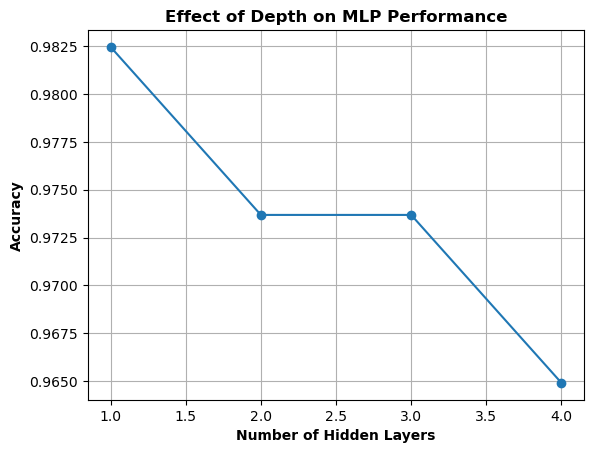

In [179]:
# Plot results
plt.figure()
plt.plot(range(1, 5), depth_results, marker='o')

# Labels and title
plt.xlabel("Number of Hidden Layers", fontweight = "semibold")
plt.ylabel("Accuracy", fontweight = "semibold")
plt.title("Effect of Depth on MLP Performance", fontweight = "semibold")

plt.grid()
plt.savefig("depth.png", dpi=144)
plt.show()

### 6. `Experiment 2: Effect of Width`

In this experiment, I examine how the number of neurons per layer (width) affects performance of the model.

The number of layers is kept constant, while the number of neurons is increased (8, 16, 32, 64).

This helps to understand how increasing the capacity of each layer influences the model's ability to learn patterns in the data.

In [187]:
# List to store results
width_results = []

# Test different neuron sizes
neuron_sizes = [8, 16, 32, 64]

for size in neuron_sizes:
    # Create model with varying width (2 layers fixed)
    model = MLPClassifier(
        hidden_layer_sizes=(size, size),
        max_iter=1000,
        random_state=42
    )
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Store result
    width_results.append(acc)
    print(acc)

0.9824561403508771
0.9736842105263158
0.9912280701754386
0.9824561403508771


### Results: Effect of Width on Performance

The plot displays how accuracy changes as the number of neurons per layer increases.

From the results:
- Performance improved from 8 neurons (~0.982) to 32 neurons (~0.991).
- For this dataset, the best performance was achieved at 32 neurons.
- Increasing to 64 neurons resulted in a noticeable drop in accuracy (~0.965), this indicates that increasing width beyond 32 neurons hurts the model performance instead of improving.

This indicates that increasing width improves performance up to a point, after which the model begins to overfit or lose generalisation ability. 

Increasing width beyond that hurts performance instead of helping.

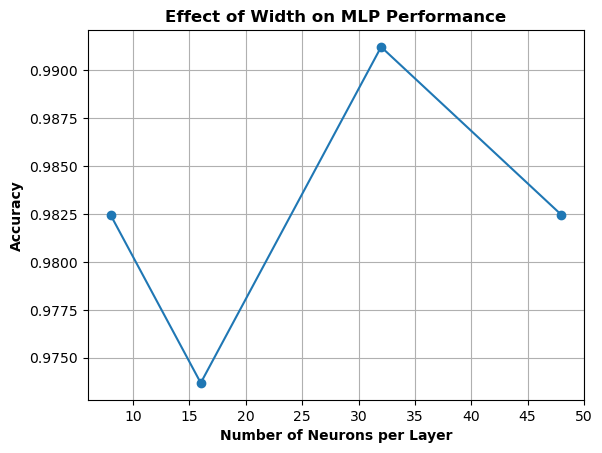

In [192]:
# Plot results
plt.figure()
plt.plot(neuron_sizes, width_results, marker='o')

# Labels and title
plt.xlabel("Number of Neurons per Layer", fontweight = "bold")
plt.ylabel("Accuracy", fontweight = "bold")
plt.title("Effect of Width on MLP Performance", fontweight = "bold")

plt.grid()
plt.savefig("width.png", dpi = 144)
plt.show()

### 7. `Overfitting Analysis (Training vs Testing Performance)`

To better understand the behaviour observed in the width experiment, I compared training accuracy with testing accuracy.

This helps identify whether the model is overfitting.

- Training accuracy shows how well the model fits the training data.
- Testing accuracy shows how well the model generalises to unseen data.

A large gap between the two indicates overfitting.

In [193]:
train_acc = []
test_acc = []

for size in neuron_sizes:
    model = MLPClassifier(
        hidden_layer_sizes=(size, size),
        max_iter=1000,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # Training accuracy
    train_acc.append(model.score(X_train, y_train))
    
    # Testing accuracy
    test_acc.append(model.score(X_test, y_test))

### Results: Overfitting Plot

The plot compares training and testing accuracy across different model sizes.

From the results:
- Training accuracy reaches 100% for larger models.
- Testing accuracy peaks at 32 neurons ~0.991 but drops significantly at 64 neurons ~0.965.

This clearly indicates overfitting:
- The model memorises the training data (high training accuracy)
- But fails to generalise to new data (lower testing accuracy)

This reinforces the earlier observation that increasing model complexity beyond a certain point is not helpful.

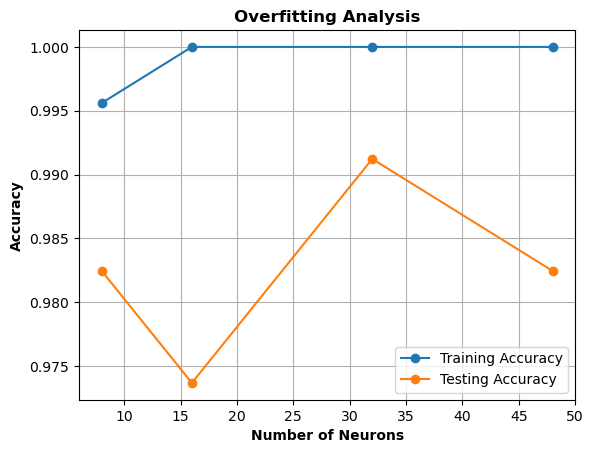

In [194]:
plt.figure()
plt.plot(neuron_sizes, train_acc, label="Training Accuracy", marker='o')
plt.plot(neuron_sizes, test_acc, label="Testing Accuracy", marker='o')

plt.xlabel("Number of Neurons", fontweight = "semibold")
plt.ylabel("Accuracy", fontweight = "semibold")
plt.title("Overfitting Analysis", fontweight = "semibold")

plt.legend()
plt.grid()

plt.savefig("overfitting.png", dpi = 144)
plt.show()

### 8. Improving the Model: Addressing Overfitting

From the above experiments, it was clear that larger models (e.g. 64 neurons) achieved very high training accuracy but lower testing accuracy. <br> This indicated overfitting, where the model learned noise, memorises the training data but fails to generalise.

To address this, I introduced the following improvements:

- Reduced model complexity by selecting 32 neurons
- Added L2 regularisation using the `alpha` parameter
- Added early stopping to prevent too much training

The updated model was then compared with the original overfitting model.

### Results

The comparison shows that:

- The overfitting model achieves near-perfect training accuracy but lower testing accuracy
- The improved model maintains high testing accuracy with a smaller gap between training and testing performance

This demonstrates that regularisation and controlled model complexity lead to better generalisation.

In [202]:
# Improved MLP model to reduce overfitting
mlp_improved = MLPClassifier(
    hidden_layer_sizes=(32,),   # Balanced width
    alpha=0.001,                # L2 regularisation
    early_stopping=True,        # Stops training early
    validation_fraction=0.1,
    max_iter=1000,
    random_state=42
)

# Train the model
mlp_improved.fit(X_train, y_train)

# Predictions
y_pred_improved = mlp_improved.predict(X_test)

# Accuracy
improved_accuracy = accuracy_score(y_test, y_pred_improved)

print("Improved Model Accuracy:", improved_accuracy)

Improved Model Accuracy: 0.8947368421052632


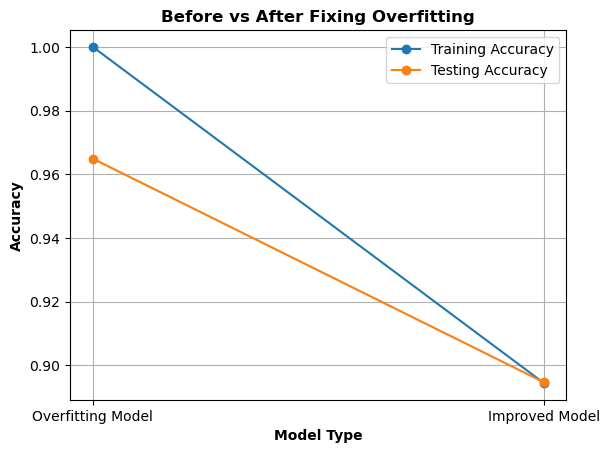

In [213]:
# Original overfitting model (example: 64 neurons)
mlp_overfit = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    max_iter=1000,
    random_state=42
)

mlp_overfit.fit(X_train, y_train)

# Accuracy comparison
train_overfit = mlp_overfit.score(X_train, y_train)
test_overfit = mlp_overfit.score(X_test, y_test)

train_improved = mlp_improved.score(X_train, y_train)
test_improved = mlp_improved.score(X_test, y_test)

# Plot comparison
models = ['Overfitting Model', 'Improved Model']
train_scores = [train_overfit, train_improved]
test_scores = [test_overfit, test_improved]

plt.figure()
x = range(len(models))

plt.plot(x, train_scores, marker='o', label='Training Accuracy')
plt.plot(x, test_scores, marker='o', label='Testing Accuracy')

plt.xticks(x, models)
plt.xlabel("Model Type", fontweight = "semibold")
plt.ylabel("Accuracy", fontweight = "semibold")
plt.title("Before vs After Fixing Overfitting", fontweight = "semibold")

plt.legend()
plt.grid()

plt.savefig("improved model plot.png", dpi = 144)
plt.show()

### `Conclusion`

From the experiments, it is clear that increasing the complexity of a neural network does not always improve performance. <br> A simple model with a moderate number of neurons performed better than deeper or wider models.

While larger models achieved very high training accuracy, they did not generalise well to unseen data. <br> After applying regularisation and reducing model complexity, the model became more balanced and achieved better overall performance.

This shows the importance of finding the right balance when designing neural networks.


### `Limitations of Analysis`

This analysis is based on a single dataset, so the results may not apply to all types of data. Different datasets may require different model architectures.

The dataset size `(569 samples)` and complexity `(due to many feature variables)` may influence the observed trends, limiting generalisability. This may have contributed to the overfitting observed.

In addition, only depth and width were explored in detail. Other factors such as learning rate, different activation functions, and optimisation methods were not investigated.

Finally, the evaluation was based mainly on accuracy, which may not capture all aspects of model performance.


### `Suggestions for Improvement / Future Work`

- Future work could explore the effect of other parameters such as different activation functions or learning rates.

- It would also be useful to test the model on different datasets to see whether the same patterns hold.

- In addition, more advanced techniques such as dropout or cross-validation could be used to further improve generalisation and reduce overfitting.

## References:
- Agarap, A.F. (2017) On breast cancer detection: An application of machine learning algorithms on the Wisconsin diagnostic dataset. Available at: https://arxiv.org/abs/1711.07831

- Goodfellow, I., Bengio, Y. and Courville, A. (2016) Deep Learning. MIT Press.

- Kingma, D.P. and Ba, J. (2014) ‘Adam: A method for stochastic optimisation’, arXiv preprint arXiv:1412.6980.

- scikit-learn (2024) MLPClassifier documentation. Available at: https://scikit-learn.org

- scikit-learn (2023) Neural network models (supervised). Available at: https://scikit-learn.org

- Wolberg, W.H., Street, W.N. and Mangasarian, O.L. (1992) Breast cancer Wisconsin dataset.

- Géron, A. (2019) Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow. O’Reilly Media.

- Agarap, A.F. (2018) ‘Deep learning using rectified linear units (ReLU)’, arXiv preprint arXiv:1803.08375.
